In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Total Chemical Potential

The total chemical potential in a fluid is given by:

$\mu = \mu_\text{id} + \mu_\text{ex}$

- $\mu_\text{id}$ is the ideal gas contribution,
- $\mu_\text{ex}$ is the excess chemical potential due to
    intermolecular interactions.

# Ideal Gas Contribution

The ideal gas chemical potential is:

$\mu_\text{id} = k_B T \ln(\rho \Lambda^3)$

where $\rho = N/V$ is the number density and $\Lambda$ is the thermal de Broglie wavelength:

$\Lambda = \sqrt{\frac{h^2}{2 \pi m k_B T}}$

- $h = 6.626 \times 10^{-34}\ \mathrm{J\ s}$ (Planck's constant),
- $m = \frac{39.962\ \mathrm{g/mol}}{6.022 \times 10^{23}}\approx 6.64\times 10^{-26}\ \mathrm{kg}$ (mass of one argon atom),
- $k_B = 1.3806 \times 10^{-23}\ \mathrm{J/K}$ (Boltzmann constant),
- $T = 84$ K.

$\to \Lambda = 0.307 \mathrm{\AA{}}$

In [7]:
mu_vs_N_gcmc_lammps = np.loadtxt("GCMC-chemical-potential-LAMMPS/number_vs_mu.dat")
mu_vs_N_gcmc_maniac = np.loadtxt("GCMC-chemical-potential-MANIAC/number_vs_mu.dat")
muex_vs_N_widom_lammps = np.loadtxt("Widom-fixed-number-LAMMPS/number_vs_muex.dat")
muex_vs_N_widom_maniac = np.loadtxt("Widom-fixed-number-MANIAC/number_vs_muex.dat")

In [8]:
Lambda = 0.3077e-10 # de Broglie wavelenght in m
T = 84 # K
kB = 1.987e-3 # kcal/mol/K
V = (40e-10)**3 # volume in m3

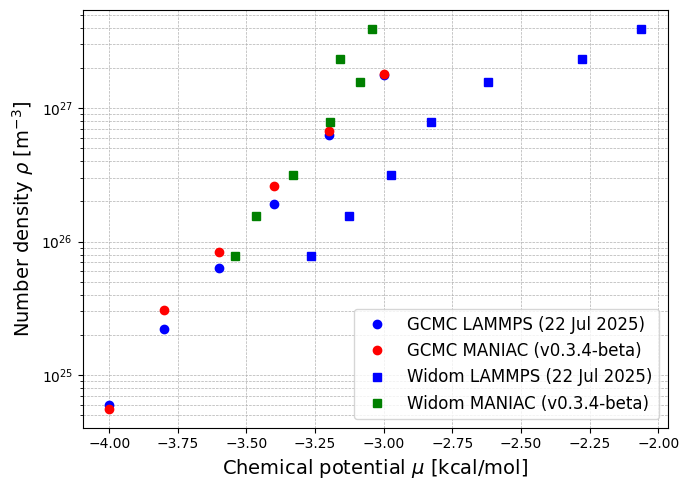

In [9]:
plt.figure(figsize=(7,5))

# From GCMC
N = mu_vs_N_gcmc_lammps[:,1] # number of particle in box
mu = mu_vs_N_gcmc_lammps[:,0] # chemical potential in kcal/mol
rho = N/V # particles per m3

plt.semilogy(mu, rho, 'o', label=r'GCMC LAMMPS (22 Jul 2025)', markersize=6, color='blue')

# From Maniac
N = mu_vs_N_gcmc_maniac[:,1] # number of particle in box
mu = mu_vs_N_gcmc_maniac[:,0] # chemical potential in kcal/mol
rho = N/V # particles per m3

plt.semilogy(mu, rho, 'o', label=r'GCMC MANIAC (v0.3.4-beta)', markersize=6, color='red')

# From Widom
N = muex_vs_N_widom_lammps[:,1] # number of particle in box
mu_ex = muex_vs_N_widom_lammps[:,0] # excess chemical potential in kcal/mol
rho = N/V # particles per m3
mu_id = kB*T * np.log(rho*Lambda**3)

mu = mu_id + mu_ex

plt.semilogy(mu, rho, 's', label=r'Widom LAMMPS (22 Jul 2025)', markersize=6, color='blue')

# From Widom
N = muex_vs_N_widom_maniac[:,1] # number of particle in box
mu_ex = muex_vs_N_widom_maniac[:,0] # excess chemical potential in kcal/mol
rho = N/V # particles per m3
mu_id = kB*T * np.log(rho*Lambda**3)

mu = mu_id + mu_ex

plt.semilogy(mu, rho, 's', label=r'Widom MANIAC (v0.3.4-beta)', markersize=6, color='green')

# Labels and legend
plt.xlabel(r'Chemical potential $\mu$ [kcal/mol]', fontsize=14)
plt.ylabel(r'Number density $\rho$ [m$^{-3}$]', fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.tight_layout()
plt.savefig("Maniac_vs_LAMMPS.png", dpi=300)
plt.show()

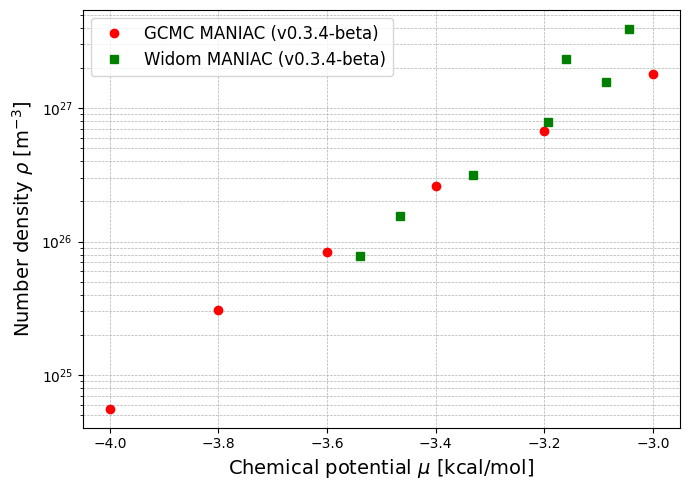

In [10]:
plt.figure(figsize=(7,5))

# From GCMC
N = mu_vs_N_gcmc_lammps[:,1] # number of particle in box
mu = mu_vs_N_gcmc_lammps[:,0] # chemical potential in kcal/mol
V = (40e-10)**3 # volume in m3
rho = N/V # particles per m3

# plt.semilogy(mu, rho, 'o', label=r'GCMC LAMMPS', markersize=6, color='blue')

# From Maniac
N = mu_vs_N_gcmc_maniac[:,1] # number of particle in box
mu = mu_vs_N_gcmc_maniac[:,0] # chemical potential in kcal/mol
V = (40e-10)**3 # volume in m3
rho = N/V # particles per m3

plt.semilogy(mu, rho, 'o', label=r'GCMC MANIAC (v0.3.4-beta)', markersize=6, color='red')

# From Widom
N = muex_vs_N_widom_lammps[:,1] # number of particle in box
mu_ex = muex_vs_N_widom_lammps[:,0] # excess chemical potential in kcal/mol
V = (40e-10)**3 # volume in m3
rho = N/V # particles per m3
mu_id = kB*T * np.log(rho*Lambda**3)

mu = mu_id + mu_ex

# plt.semilogy(mu, rho, 's', label=r'Widom LAMMPS', markersize=6, color='blue')

# From Widom
N = muex_vs_N_widom_maniac[:,1] # number of particle in box
mu_ex = muex_vs_N_widom_maniac[:,0] # excess chemical potential in kcal/mol
V = (40e-10)**3 # volume in m3
rho = N/V # particles per m3
mu_id = kB*T * np.log(rho*Lambda**3)

mu = mu_id + mu_ex

plt.semilogy(mu, rho, 's', label=r'Widom MANIAC (v0.3.4-beta)', markersize=6, color='green')

# Labels and legend
plt.xlabel(r'Chemical potential $\mu$ [kcal/mol]', fontsize=14)
plt.ylabel(r'Number density $\rho$ [m$^{-3}$]', fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.tight_layout()
plt.savefig("GCMC_vs_Widom.png", dpi=300)
plt.show()